## Industry rule for this stage

**Rule:** cleaning decisions (null handling, outlier capping) must be *fit on train only* and applied unchanged to test — never recompute statistics (median, IQR bounds, quantiles) from the test set. **Naming rule:** each intermediate save gets its own distinct filename so later notebooks can't accidentally load the wrong stage of the data.


In [ ]:
# import required libraries and add project root to the path
import sys
sys.path.append("../")

from multiple_stage_notebooks import *

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load the processed dataset and preview it
df = pd.read_csv("../data/processed/df.csv")

print(df.head())

   Age  Income Home_ownership  Employment_length Loan_intent  \
0   22   59000           Rent              123.0    Personal   
1   21    9600            Own                5.0   Education   
2   25    9600       Mortgage                1.0     Medical   
3   23   65500           Rent                4.0     Medical   
4   24   54400           Rent                8.0     Medical   

  internal_credit_rating  Loan_amount  Interest_rate  Loan_status  \
0                      D        35000          16.02            1   
1                      B         1000          11.14            0   
2                      C         5500          12.87            1   
3                      C        35000          15.23            1   
4                      C        35000          14.27            1   

   Loan_percent_income Default  Credit_history_length  
0                 0.59       Y                      3  
1                 0.10       N                      2  
2                 0.57       N  

## Handling Duplicate Values

In [4]:
# check number of duplicate rows in dataframe
def check_duplicates(df):
  return df.duplicated().sum()

# remove duplicate rows from dataframe
def drop_duplicates(df):
  df.drop_duplicates(inplace=True)
  print("Duplicates Removed")

In [5]:
# check total duplicate rows
duplicates = check_duplicates(df)
print("Total Number of duplicates in a dataframe : ", duplicates)

# remove duplicates if present
if duplicates > 0:
  print(f"We Removing {duplicates} rows of dataframe")
  drop_duplicates(df)

Total Number of duplicates in a dataframe :  165
We Removing 165 rows of dataframe
Duplicates Removed


## Split the df

In [6]:
def split_and_save(df, target_col, test_size=0.2, random_state=42):

    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y if y.nunique() < 20 else None
    )

    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)

    return train_df, test_df

In [7]:
train_df, test_df = split_and_save(df, 'Loan_status', 0.2, 42)

Now save it into csv format file

In [8]:
# Save (industry common formats)
train_df.to_csv("../data/processed/train_df.csv", index=False)
test_df.to_csv("../data/processed/test_df.csv", index=False)

In [9]:
train_df.shape, test_df.shape

((25932, 12), (6484, 12))

Missing-value mechanisms (MCAR / MAR / MNAR)
> - **What it is:** A way to classify *why* a value is missing — MCAR (missing completely at random, no pattern), MAR (missingness relates to other observed columns), MNAR (missingness relates to the missing value itself).
> - **Why we check it here:** The correct fix depends on the mechanism — filling MAR data with a plain mean/median (ignoring the related column) would bias the feature, so we need to know the type before picking a strategy.
<!-- > - **What we achieved:** Only `Employment_length` and `Interest_rate` had nulls, both diagnosed as MAR (related to `Age`/other columns) — so we used **group-median imputation** (Employment_length, grouped by Age bucket) and **model-based imputation** (Interest_rate) instead of a naive fillna. -->


## Handling Null Values

In [10]:
# function to analyze missing values in dataframe
def handle_null(df):
  if df is None:
    raise ValueError("Input DataFrame is None....")

  # calculate missing values count and percentage
  result = df.isnull().agg(['sum', 'mean']).T
  result.columns = ['null_count', 'null_percent']

  # keep only columns having missing values
  result = result[result['null_count'] != 0]

  # convert ratio to percentage
  result['null_percent'] = result['null_percent'] * 100

  return result

#### Checking Null Values

In [11]:
print("Null columns of train dataframe with percent of null....\n")
handle_null(train_df)

Null columns of train dataframe with percent of null....



,null_count,null_percent
Employment_length,727.0,2.803486
Interest_rate,2488.0,9.594324


In [12]:
print("Null columns of test dataframe with percent of null....\n")
handle_null(test_df)

Null columns of test dataframe with percent of null....



,null_count,null_percent
Employment_length,160.0,2.467613
Interest_rate,607.0,9.361505


Observation - Both columns has more important for prediction and It doesn't have many null values. that's why we need to fill them

In [13]:
# function to plot KDE distribution for given columns
def kde_plot(df, cols):
  if df is None:
    raise ValueError("DataFrame is None")

  # validate columns exist in dataframe
  for col in cols:
    if col not in df.columns:
      raise ValueError(f"{col} not found in DataFrame")

  # create subplots for each column
  fig, axes = plt.subplots(nrows=1, ncols=len(cols), figsize=(12, 6))

  # handle single column case
  if len(cols) == 1:
    axes = [axes]

  # plot KDE for each column
  for ax, col in zip(axes, cols):
    sns.kdeplot(df[col], ax=ax, warn_singular=False)
    ax.set_title(col)
    ax.grid(True)

  # adjust layout spacing
  plt.tight_layout(pad=0.8)

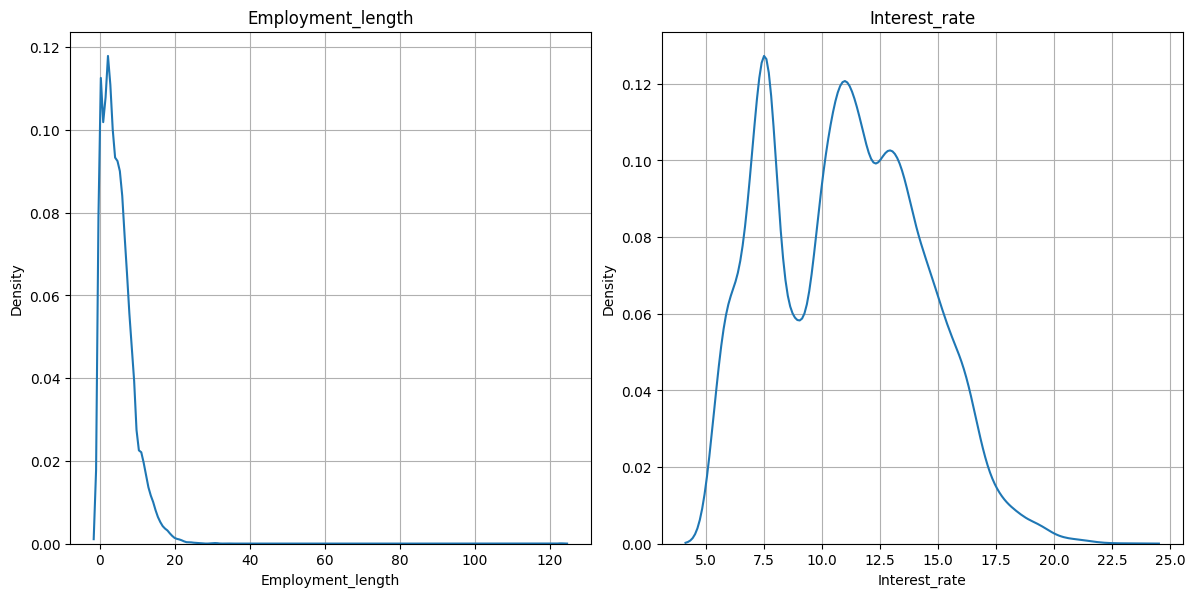

In [14]:
# select columns that contain missing values
cols = train_df.columns[train_df.isnull().any()]

# plot KDE distributions for columns with missing values
kde_plot(train_df, cols)

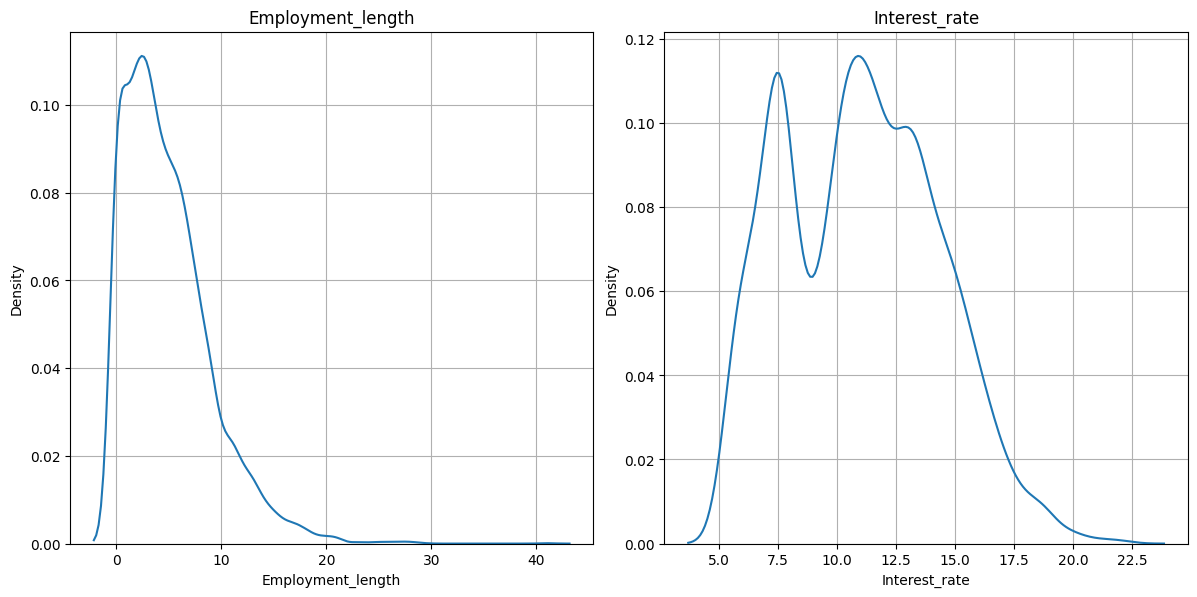

In [15]:
# select columns that contain missing values
cols = test_df.columns[test_df.isnull().any()]

# plot KDE distributions for columns with missing values
kde_plot(test_df, cols)

#### Filling Missing Values

#### Group based Median for Employment Length

<!-- Observation - There is three main types of Null values....

1. MCAR (No pattern, Random missing values)
2. MAR (Related to other observed variables)
3. MNAR (Unobserved value itself) -->

Observation - Here, Employment length and Interest rate is both column is associated with other their relative columns that's why it's MAR....

we need to missing it based on

Group median or model based imputation.....

accroding to Nan values in Emp_length we use Group based median for easy and efficient way to fill

in Interest rate % of Nan is high that's why model based imputation is good....

In [16]:
# create working copies of train/test data for employment-length imputation
train_df_nan_fill_at_emp_col = train_df.copy()
test_df_nan_fill_at_emp_col = test_df.copy()

In [17]:
# check correlation between Age, Income and Employment_length
train_df_nan_fill_at_emp_col[['Age','Income','Employment_length']].corr()

,Age,Income,Employment_length
Age,1.000000,0.179741,0.156391
Income,0.179741,1.000000,0.127396
Employment_length,0.156391,0.127396,1.000000


Here, we see Employement is more relative to the Age so we make a bins of age column

In [18]:
def fill_with_group_median(df_process, col_to_bin, target_col, bins, labels, is_train=True, mapping_store=None, overall_median_from_train=None):

    df_process = df_process.copy()

    binned_column_name = f"{col_to_bin}_Binned"

    df_process[binned_column_name] = pd.cut(
        df_process[col_to_bin],
        bins=bins,
        labels=labels
    )

    if is_train:
        mapping_store = {}

    for col in target_col:

        if is_train:
            group_medians = df_process.groupby(binned_column_name)[col].median()
            mapping_dict = group_medians.to_dict()
            mapping_store[col] = mapping_dict
            overall_median = df_process[col].median()
        else:
            mapping_dict = mapping_store[col]
            overall_median = None  # will fill later from train if needed

        missing_mask = df_process[col].isna()
        df_process.loc[missing_mask, col] = df_process.loc[missing_mask, binned_column_name].map(mapping_dict)

        if df_process[col].isna().sum() > 0:
            if is_train:
                df_process[col].fillna(overall_median, inplace=True)
            else:
                # fallback: use train overall median
                df_process[col].fillna(overall_median_from_train[col], inplace=True)

    return df_process, mapping_store

In [19]:
train_df_imputed, mapping_store = fill_with_group_median(train_df_nan_fill_at_emp_col, 'Age', ['Employment_length'], bins=[0, 28, 40, 100], labels=['Young', 'Middle', 'Senior'], is_train=True)

overall_median_from_train = {c: train_df_imputed[c].median() for c in ['Employment_length']}

In [20]:
# preview imputed train dataframe
train_df_imputed.head()

,Age,Income,Home_ownership,Employment_length,Loan_intent,internal_credit_rating,Loan_amount,Interest_rate,Loan_percent_income,Default,Credit_history_length,Loan_status,Age_Binned
7173,23,75800,Rent,0.0,Personal,A,7000,6.54,0.09,N,2,0,Young
16396,25,61959,Rent,9.0,Education,C,25000,12.73,0.40,Y,4,1,Young
21744,31,53088,Rent,0.0,Personal,A,6000,6.54,0.11,N,9,0,Middle
27805,27,228000,Mortgage,12.0,Homeimprovement,A,6000,7.14,0.03,N,6,0,Young
24563,29,54000,Rent,0.0,Personal,D,10000,14.96,0.19,N,9,1,Middle


In [21]:
# drop temporary binned column
train_df_imputed.drop('Age_Binned', axis = 1, inplace = True)

In [22]:
# verify no missing values remain in Employment_length
train_df_imputed['Employment_length'].isnull().sum()

np.int64(0)

In [23]:
# impute missing Employment_length values in test set using train mapping
test_df_imputed, _ = fill_with_group_median(test_df_nan_fill_at_emp_col, 
                                            'Age', ['Employment_length'], 
                                            bins=[0, 28, 40, 100], 
                                            labels=['Young', 'Middle', 'Senior'], 
                                            is_train=False, 
                                            mapping_store=mapping_store, 
                                            overall_median_from_train=overall_median_from_train)

In [24]:
# preview imputed test dataframe
test_df_imputed.head()

,Age,Income,Home_ownership,Employment_length,Loan_intent,internal_credit_rating,Loan_amount,Interest_rate,Loan_percent_income,Default,Credit_history_length,Loan_status,Age_Binned
21278,28,56461,Rent,5.0,Education,E,5400,15.68,0.10,Y,6,0,Young
26976,30,108000,Mortgage,0.0,Debtconsolidation,B,4925,NaN,0.05,N,9,1,Middle
26455,29,102000,Own,10.0,Medical,B,18000,9.33,0.18,N,7,0,Middle
24178,29,45000,Rent,4.0,Venture,B,10000,12.42,0.22,N,7,0,Middle
25069,31,30000,Rent,4.0,Debtconsolidation,B,12000,10.39,0.40,N,9,1,Middle


In [25]:
# drop temporary binned column
test_df_imputed.drop('Age_Binned', axis = 1, inplace = True)

In [26]:
# verify no missing values remain in Employment_length
test_df_imputed['Employment_length'].isnull().sum()

np.int64(0)

In [27]:
# store cleaned train dataframe
clean_emp_col_train_df = train_df_imputed.copy()

In [28]:
# store cleaned test dataframe
clean_emp_col_test_df = test_df_imputed.copy()

Fill The Missing Data on Interest rate with Model based imputation

Fill The Missing Data Based on Model Based Imputation

In [29]:
def preprocess_missing_values(train_df, test_df):

    train_df = train_df.copy()
    test_df = test_df.copy()
    
    X_train = train_df.drop('Loan_status', axis=1)
    y_train = train_df['Loan_status']
    X_test = test_df.drop('Loan_status', axis=1)
    y_test = test_df['Loan_status']
    
    num_cols = X_train.select_dtypes(include=['int64', 'float64', 'Int64']).columns

    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    knn = KNNImputer(n_neighbors=5)
    X_train[num_cols] = knn.fit_transform(X_train[num_cols])
    X_test[num_cols] = knn.transform(X_test[num_cols])

    # sirf num_cols ko inverse transform karo, columns=num_cols use karo (X_train.columns nahi)
    X_train[num_cols] = scaler.inverse_transform(X_train[num_cols])
    X_test[num_cols] = scaler.inverse_transform(X_test[num_cols])

    train_df_clean = X_train.copy()
    train_df_clean['Loan_status'] = y_train.values
    
    test_df_clean = X_test.copy()
    test_df_clean['Loan_status'] = y_test.values
    
    return train_df_clean, test_df_clean

In [30]:
# Usage
train_clean, test_clean = preprocess_missing_values(clean_emp_col_train_df, clean_emp_col_test_df)

In [31]:
# Save dataframe
train_clean.to_csv("../data/processed/no_nan_train_df.csv", index=False)
test_clean.to_csv("../data/processed/no_nan_test_df.csv", index=False)

## Data Type Fixing

Convert 0/1 columns in a dataframe to boolean type.

Parameters:
df (pd.DataFrame): input dataframe
is_train (bool): just for logging/printing context

Returns:
pd.DataFrame: updated dataframe


In [32]:
def convert_binary_to_bool(df, is_train=True):
    for col in df.columns:
        print(f"\n{'[TRAIN]' if is_train else '[TEST]'} Column: {col}")
        print("Before:", df[col].dtype)

        # check if column contains only 0 and 1 values
        if set(df[col]).issubset({0, 1}):
            df[col] = df[col].astype(bool)

        print("After:", df[col].dtype)

In [33]:
# convert binary columns to boolean in train set
convert_binary_to_bool(train_clean, is_train=False)


[TEST] Column: Age
Before: float64
After: float64

[TEST] Column: Income
Before: float64
After: float64

[TEST] Column: Home_ownership
Before: object
After: object

[TEST] Column: Employment_length
Before: float64
After: float64

[TEST] Column: Loan_intent
Before: object
After: object

[TEST] Column: internal_credit_rating
Before: object
After: object

[TEST] Column: Loan_amount
Before: float64
After: float64

[TEST] Column: Interest_rate
Before: float64
After: float64

[TEST] Column: Loan_percent_income
Before: float64
After: float64

[TEST] Column: Default
Before: object
After: object

[TEST] Column: Credit_history_length
Before: float64
After: float64

[TEST] Column: Loan_status
Before: int64
After: bool


In [34]:
# convert binary columns to boolean in test set
convert_binary_to_bool(test_clean, is_train=False)


[TEST] Column: Age
Before: float64
After: float64

[TEST] Column: Income
Before: float64
After: float64

[TEST] Column: Home_ownership
Before: object
After: object

[TEST] Column: Employment_length
Before: float64
After: float64

[TEST] Column: Loan_intent
Before: object
After: object

[TEST] Column: internal_credit_rating
Before: object
After: object

[TEST] Column: Loan_amount
Before: float64
After: float64

[TEST] Column: Interest_rate
Before: float64
After: float64

[TEST] Column: Loan_percent_income
Before: float64
After: float64

[TEST] Column: Default
Before: object
After: object

[TEST] Column: Credit_history_length
Before: float64
After: float64

[TEST] Column: Loan_status
Before: int64
After: bool


Outlier detection (IQR method)
> - **What it is:** IQR (Interquartile Range = Q3 − Q1) based rule — any value below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` is flagged as an outlier. Visualized here with KDE and box plots, then quantified as a % per column.
> - **Why we use it:** It's a distribution-free, easy-to-audit rule (no normality assumption needed) — for our model we just create and preserve outlier df and did not cap it because random forest will handle perfectly.


## Outlier Detection

#### Outliers checking using kde plot

In [35]:
# function to plot KDE distributions for all numerical columns

def plot_kde_distributions(df):

    # select numerical columns
    cols = df.select_dtypes(include=['int64', 'float64']).columns

    # define grid size
    n_cols = 5
    n_rows = (len(cols) + n_cols - 1) // n_cols

    plt.figure(figsize=(20, 4 * n_rows))

    # plot KDE for each numerical column
    for i, col in enumerate(cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.kdeplot(df[col], fill=True)
        plt.title(col, fontsize=12, fontweight='bold')
        plt.grid(alpha=0.3)
        plt.xlabel("")
        plt.ylabel("")

    # overall title
    plt.suptitle("Distribution of Numerical Features", fontsize=16, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

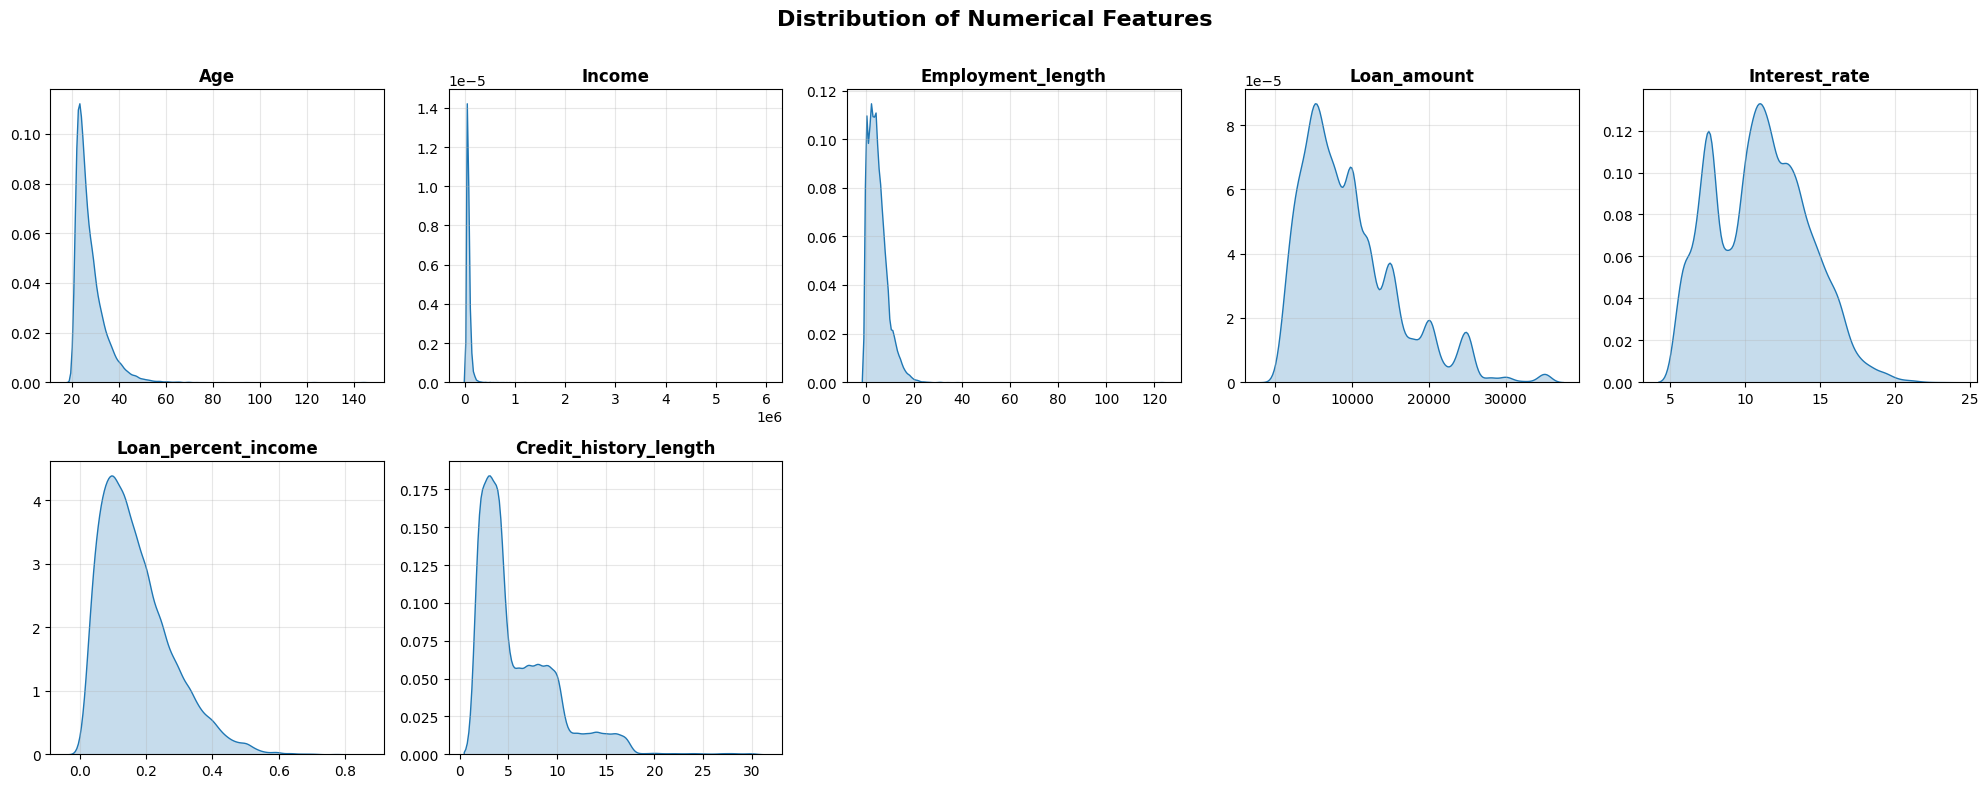

In [36]:
plot_kde_distributions(train_clean)

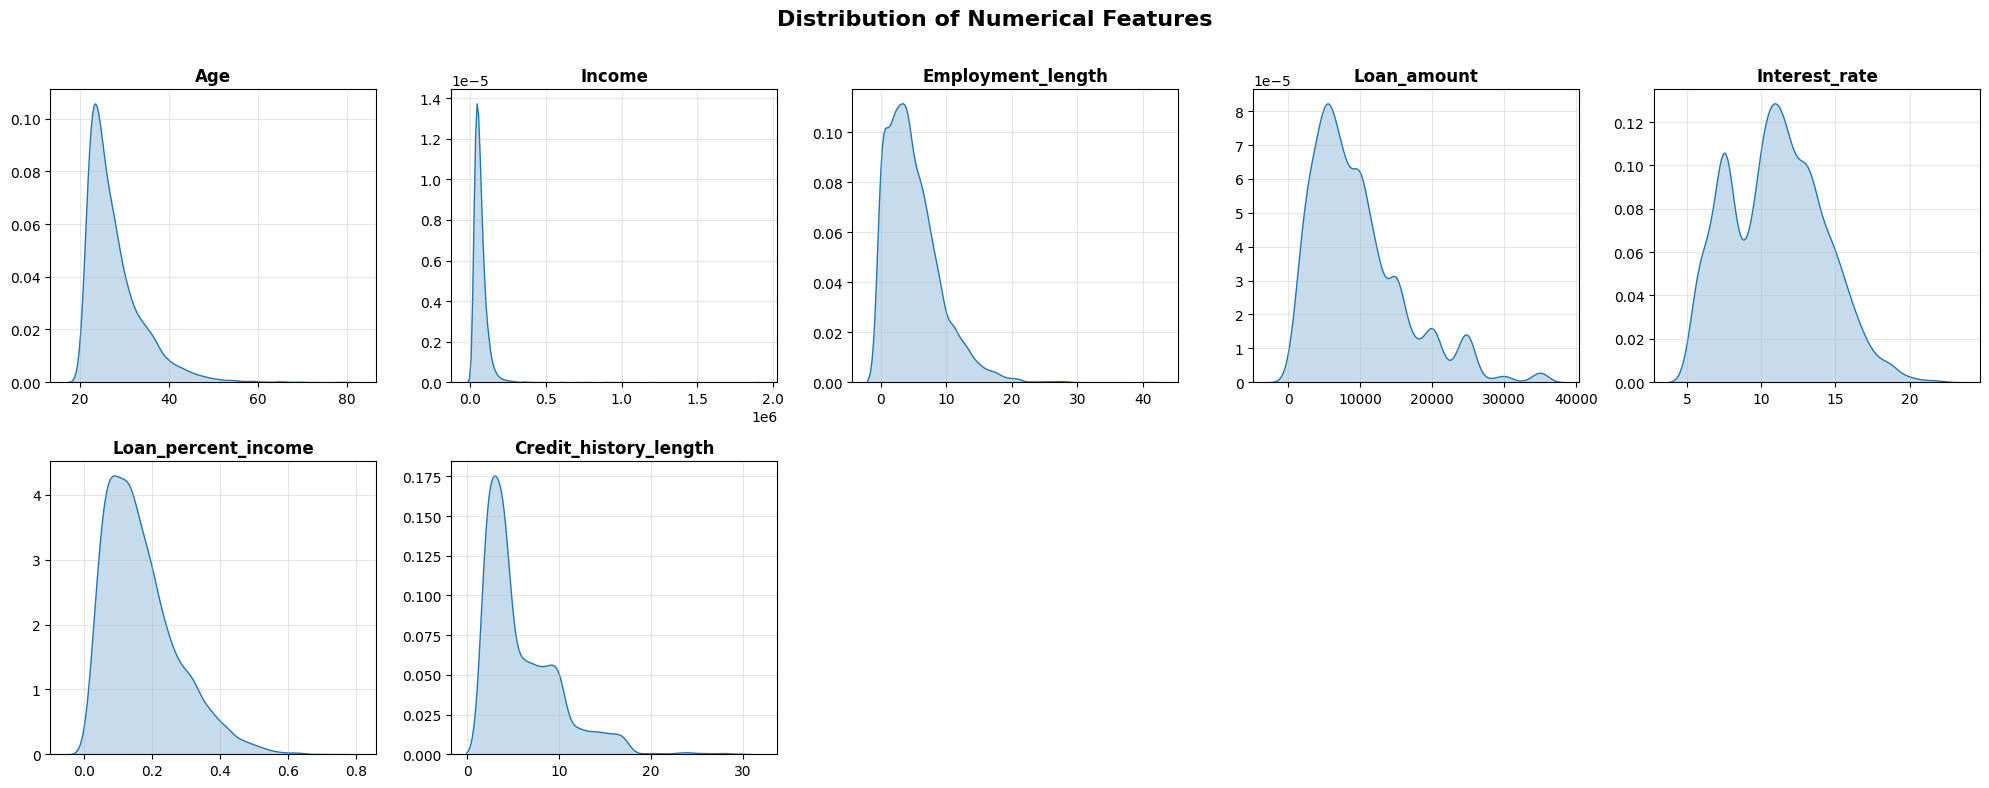

In [37]:
plot_kde_distributions(test_clean)

Observation -
You can see all the columns has right skewed plot that shows heavy outliers in it. specially in Income

#### Outliers checking using Box plot

In [38]:
# function to plot boxplots for all numerical columns

def plot_boxplots(df):

    # select numerical columns
    cols = df.select_dtypes(include=['int64', 'float64']).columns

    # define grid size
    n_cols = 5
    n_rows = (len(cols) + n_cols - 1) // n_cols

    plt.figure(figsize=(20, 4 * n_rows))

    # overall title
    plt.suptitle('Box Plot of Numerical Features', fontsize=18, fontweight='bold', y=1.02)

    # plot boxplot for each numerical column
    for i, col in enumerate(cols, 1):
        plt.subplot(n_rows, n_cols, i)

        sns.boxplot(y=df[col])  # vertical boxplot

        plt.title(col, fontsize=11, fontweight='bold')
        plt.grid(alpha=0.2)
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

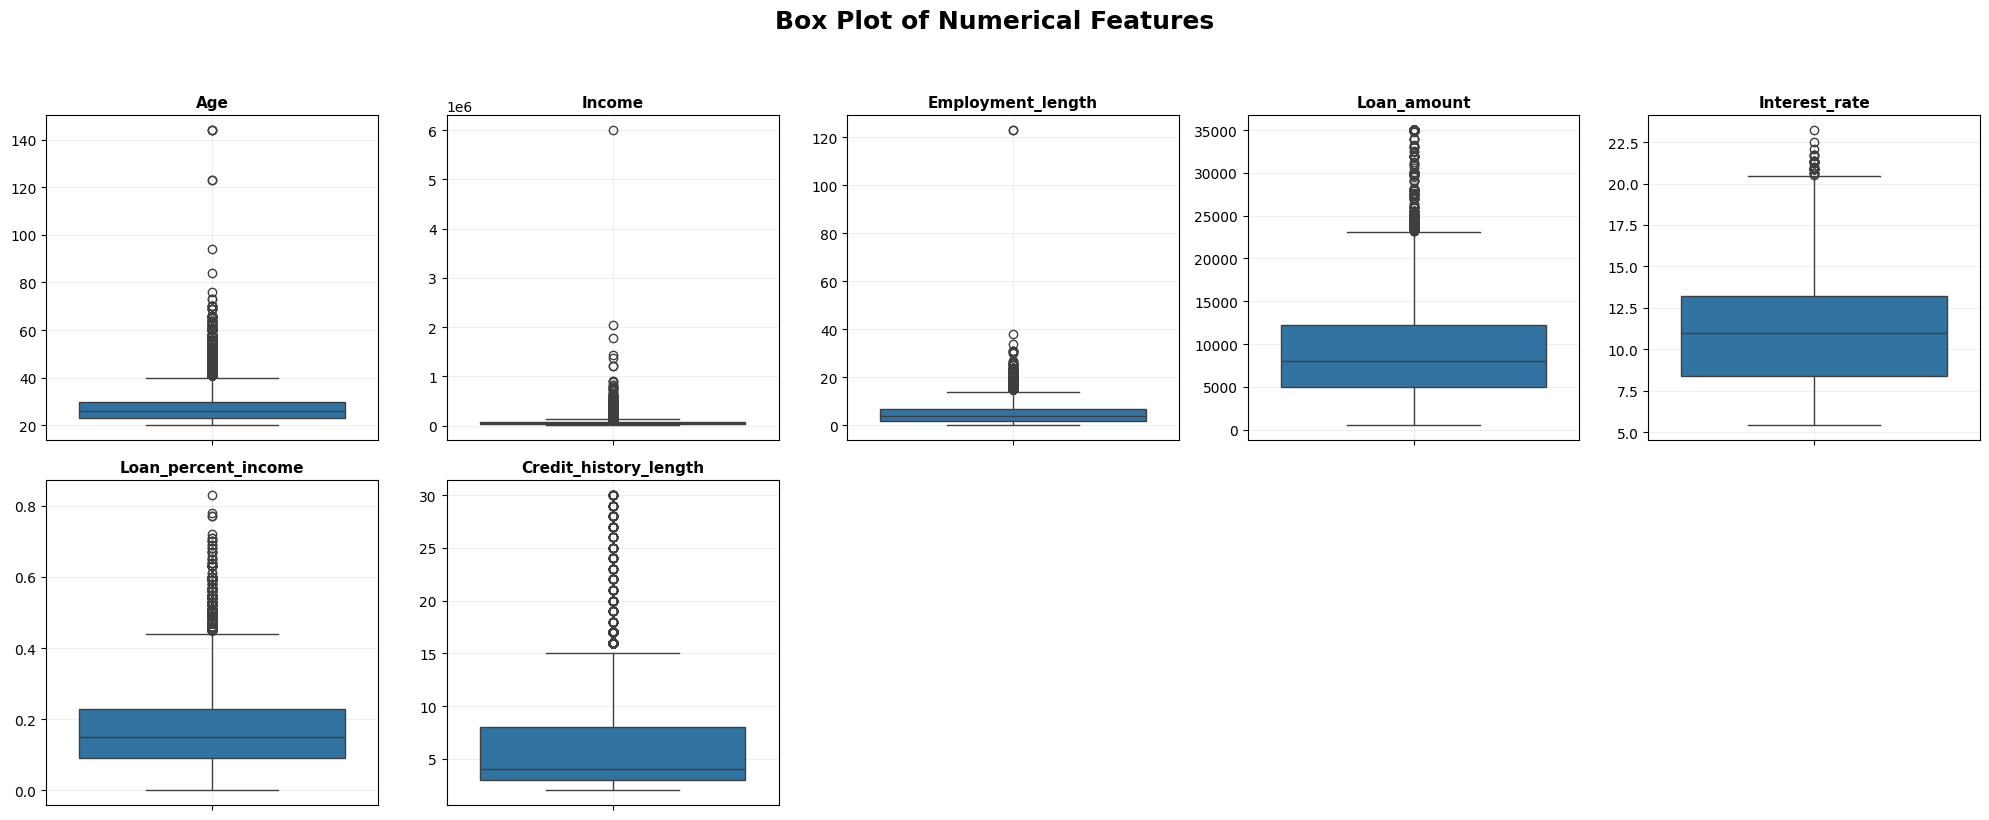

In [39]:
plot_boxplots(train_clean)

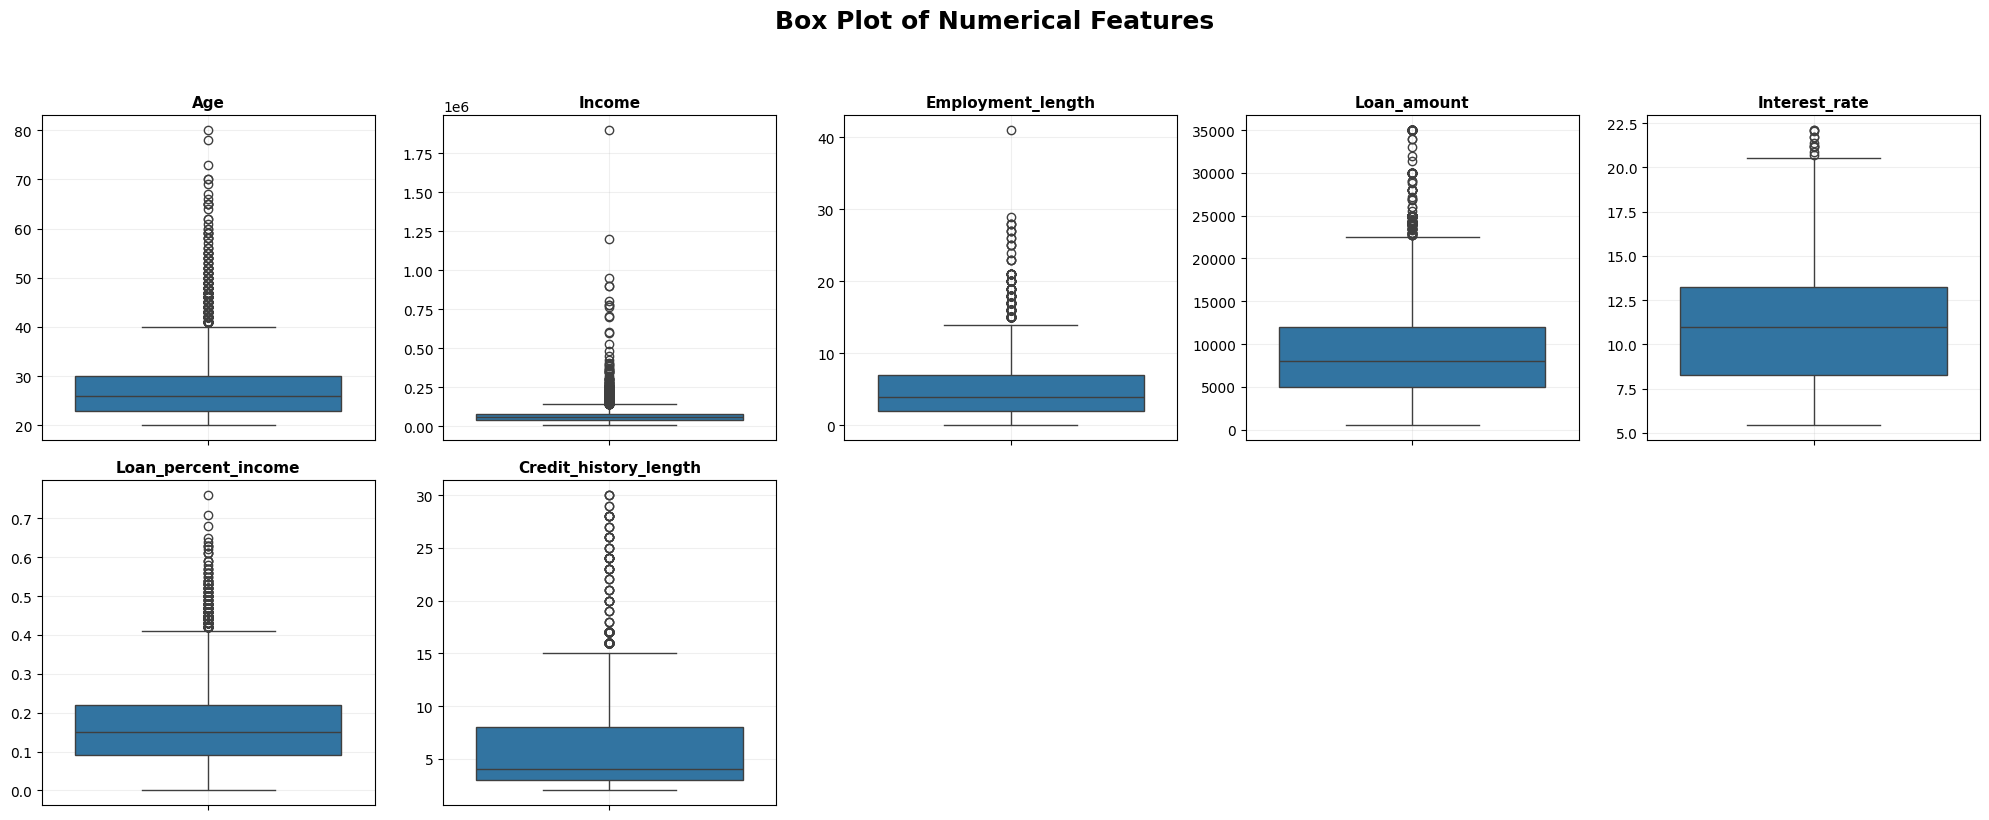

In [40]:
plot_boxplots(test_clean)

#### Outlier % checking for each columns

In [41]:
# Outlier % check using the IQR (Interquartile Range) rule
# What: flags values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] as outliers
# Why: distribution-free way to quantify how much each column is affected by extreme values

# function to check number and percentage of outliers in each numerical column
def each_col_outliers_propotion_check(df):

  # iterate over numerical columns
  for col in df.select_dtypes(include=['int64', 'float64']).columns:

    # calculate IQR range
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # define lower and upper bounds
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # count outliers
    out_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    print("Outliers count of", col, ":", out_count)
    print("Average outliers of", col, ":", round((out_count / df.shape[0]) * 100, 2), "\n")

In [42]:
# check outlier proportions in train set
each_col_outliers_propotion_check(train_clean)

Outliers count of Age : 1187
Average outliers of Age : 4.58 

Outliers count of Income : 1278
Average outliers of Income : 4.93 

Outliers count of Employment_length : 669
Average outliers of Employment_length : 2.58 

Outliers count of Loan_amount : 1307
Average outliers of Loan_amount : 5.04 

Outliers count of Interest_rate : 33
Average outliers of Interest_rate : 0.13 

Outliers count of Loan_percent_income : 522
Average outliers of Loan_percent_income : 2.01 

Outliers count of Credit_history_length : 906
Average outliers of Credit_history_length : 3.49 



Observation - Income and Credit_history_length has higher outliers % rate. we should do capping.
Age (meaning less), Loan_status (due to the binary type values) can not make any sense

#### Outlier DF

In [43]:
# Outlier extraction using the same IQR rule
# What: pulls out the actual outlier rows (not just the %) for the flagged columns
# Why: lets us inspect/save the outlier rows separately instead of just counting them
 
# function to extract outlier rows based on given columns
def get_outlier_df(df, cols):

    # iterate through selected columns and detect outliers
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # filter outlier rows for current column
        outliers_df = df[(df[col] < lower) | (df[col] > upper)]

    # return last computed outlier dataframe
    return outliers_df

In [44]:
# extract outlier rows for numerical columns in train and test sets
train_clean_numerical_columns = train_clean.select_dtypes(include=['int64', 'float64']).columns
test_clean_numerical_columns = test_clean.select_dtypes(include=['int64', 'float64']).columns

outlier_train_df = get_outlier_df(train_clean, train_clean_numerical_columns)
outlier_test_df = get_outlier_df(test_clean, test_clean_numerical_columns)

In [45]:
outlier_train_df.shape, outlier_test_df.shape

((906, 12), (233, 12))

In [46]:
# Save (industry common formats)
outlier_train_df.to_csv("../data/processed/outlier_train_df.csv", index=False)
outlier_test_df.to_csv("../data/processed/outliers_test_df.csv", index=False)

We isolate our outlier df which have only outliers (for backup or analysis of extreme groups)

#### outliers handling using Caping method

In [47]:
def detect_outliers_and_capping(df, col, is_return, is_print):

    # Step 1: IQR calculation
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Step 2: Domain rule (no negative if not allowed)
    if lower_limit < 0:
        lower_limit = 0

    if is_print:
        print(f"\n#### {col} ####")
        print("Lower limit:", lower_limit)
        print("Upper limit:", upper_limit)
    
    if is_return:
        return [lower_limit, upper_limit]

In [48]:
for col in train_clean_numerical_columns:
  detect_outliers_and_capping(train_clean, col, is_return=False, is_print=True)


#### Age ####
Lower limit: 12.5
Upper limit: 40.5

#### Income ####
Lower limit: 0
Upper limit: 139009.375

#### Employment_length ####
Lower limit: 0
Upper limit: 14.5

#### Loan_amount ####
Lower limit: 0
Upper limit: 23125.0

#### Interest_rate ####
Lower limit: 1.120000000000001
Upper limit: 20.48

#### Loan_percent_income ####
Lower limit: 0
Upper limit: 0.44000000000000006

#### Credit_history_length ####
Lower limit: 0
Upper limit: 15.5


Checking the unique values of each columns

In [49]:
for col in test_clean_numerical_columns:
  detect_outliers_and_capping(test_clean, col, is_return=False, is_print=True)


#### Age ####
Lower limit: 12.5
Upper limit: 40.5

#### Income ####
Lower limit: 0
Upper limit: 141500.0

#### Employment_length ####
Lower limit: 0
Upper limit: 14.5

#### Loan_amount ####
Lower limit: 0
Upper limit: 22500.0

#### Interest_rate ####
Lower limit: 0.8262500000000017
Upper limit: 20.65625

#### Loan_percent_income ####
Lower limit: 0
Upper limit: 0.41500000000000004

#### Credit_history_length ####
Lower limit: 0
Upper limit: 15.5


In [50]:
# print unique values for each column
for col in train_clean.columns:
  print(col)
  print(train_clean[col].unique(), "\n")

Age
[ 23.  25.  31.  27.  29.  21.  22.  24.  28.  26.  40.  35.  42.  39.
  50.  34.  33.  30.  44.  43.  32.  36.  37.  38.  41.  45.  48.  51.
  58.  46.  49.  57.  62.  47.  53.  56.  69.  52.  20.  60.  55. 123.
  61.  54.  64.  65.  66.  73.  70.  76.  63. 144.  84.  94.  59.] 

Income
[ 75800.  61959.  53088. ...  61425.  64125. 175436.] 

Home_ownership
['Rent' 'Mortgage' 'Own' 'Other'] 

Employment_length
[  0.   9.  12.   4.   3.   6.   1.   2.   5.   7.   8.  17.  15.  13.
  10.  11.  14.  16.  19.  26.  34.  18.  21.  22.  31.  20.  23.  24.
  25. 123.  27.  30.  38.] 

Loan_intent
['Personal' 'Education' 'Homeimprovement' 'Medical' 'Debtconsolidation'
 'Venture'] 

internal_credit_rating
['A' 'C' 'D' 'B' 'E' 'G' 'F'] 

Loan_amount
[ 7000. 25000.  6000. 10000.  3000.  8000. 18000. 16000. 13000. 16800.
 15000. 21600.  5000.  9000. 10850. 12000.  7500.  1500. 10200.  1600.
  3925. 27600.  9250. 10150.  6575.  2500.  4000. 20000.  5500. 14500.
 22000.  2000.  2400.  9225.  350

Observation - As you can here see in Age and Employment Length there is above 100 showing data entry error.

In [51]:
# print unique values for each column
for col in test_clean.columns:
  print(col)
  print(test_clean[col].unique(), "\n")

Age
[28. 30. 29. 31. 34. 23. 36. 35. 43. 22. 26. 21. 39. 24. 32. 37. 42. 33.
 27. 40. 25. 38. 45. 47. 44. 41. 48. 53. 55. 50. 58. 70. 49. 46. 52. 51.
 54. 65. 62. 56. 78. 61. 20. 67. 66. 60. 59. 64. 69. 80. 73. 57.] 

Income
[ 56461. 108000. 102000. ...  28008.  47760.  47300.] 

Home_ownership
['Rent' 'Mortgage' 'Own' 'Other'] 

Employment_length
[ 5.  0. 10.  4.  6.  2. 27.  3.  1. 11.  7.  8.  9. 13. 16. 14. 17. 12.
 15. 28. 19. 25. 18. 20. 21. 23. 26. 29. 41. 24.] 

Loan_intent
['Education' 'Debtconsolidation' 'Medical' 'Venture' 'Homeimprovement'
 'Personal'] 

internal_credit_rating
['E' 'B' 'C' 'F' 'D' 'A' 'G'] 

Loan_amount
[ 5400.  4925. 18000. 10000. 12000.  9600. 16000.  7500. 24250.  8000.
 15000. 14400.  5000. 14000. 19600.  4000.  5600.  2200.  4500.  4200.
 20000.  6000.  9150.  1500.  5200.  3000.  4800.  7000. 22000.  9000.
  5775.  3500.  1300. 13000.  1200. 12500. 24000.  2800.  5125. 35000.
  7200.  7600.  8400. 20500.  7800. 13500. 25000.  6600. 12800. 31400.
 1525

##### Outliers capping based on columns

Industry standard: detect and define outlier rules using train set only, then apply the same rules unchanged to the test set (no fitting on test data to avoid data leakage).

In [52]:
# Age column > 100 we take upper limit which is 40. 
capped_train_df = train_clean.copy()
capped_test_df = test_clean.copy()

upper_limit_age = int(detect_outliers_and_capping(capped_train_df, 'Age', is_return=True, is_print=False)[1])

capped_train_df.loc[capped_train_df['Age'] >= 100, 'Age'] = upper_limit_age
capped_test_df.loc[capped_test_df['Age'] >= 100, 'Age'] = upper_limit_age

In [53]:
# Here you can see age is nearly 22 so we need to assign lower limit of train_df not upper limit....

lower_limit_emp_length = int(detect_outliers_and_capping(capped_train_df, 'Employment_length', is_return=True, is_print=False)[0])

capped_train_df.loc[capped_train_df['Employment_length'] >= 100, 'Employment_length'] = lower_limit_emp_length
capped_test_df.loc[capped_test_df['Employment_length'] >= 100, 'Employment_length'] = lower_limit_emp_length

In [54]:
upper_limit_income_train = int(detect_outliers_and_capping(capped_train_df, 'Income', is_return=True, is_print=False)[1])
upper_limit_income_test = int(detect_outliers_and_capping(capped_test_df, 'Income', is_return=True, is_print=False)[1])

print(capped_train_df[capped_train_df['Income'] >= upper_limit_income_train].shape)
print(capped_test_df[capped_test_df['Income'] >= upper_limit_income_test].shape)

(1278, 12)
(295, 12)


Here in trainf_df total 1278 rows and test_df 295 are above upper limit of income so we capping it to 99% quantile of income 

In [55]:
# Step 1: rule sirf train se banao
upper = capped_train_df['Income'].quantile(0.99)

# Step 2: apply same rule on both
capped_train_df['Income'] = capped_train_df['Income'].clip(upper=upper)
capped_test_df['Income']  = capped_test_df['Income'].clip(upper=upper)

Observation - Here there is huge amount of data beyond the upper limit so it's not called true outliers.

In [56]:
upper_limit_loan_amount = int(detect_outliers_and_capping(capped_train_df, 'Loan_amount', is_return=True, is_print=False)[1])

capped_train_df[capped_train_df['Loan_amount'] >= upper_limit_loan_amount].shape

(1307, 12)

Observation - Also, Here there is huge amount of data beyond the upper limit so it's not called true outliers.

Here total 1307 rows are above upper limit of Loan amount so we capping it to 99% quantile of Loan amount 

In [57]:
loan_amt_upper = capped_train_df['Loan_amount'].quantile(0.99)

capped_train_df['Loan_amount'] = capped_train_df['Loan_amount'].clip(upper=loan_amt_upper)
capped_test_df['Loan_amount']  = capped_test_df['Loan_amount'].clip(upper=loan_amt_upper)

Now we have to rebuilt loan percent column because we do capping in Income that's why new reformed column is neccessary.  

In [58]:
capped_train_df['Loan_percent_income'] = round(capped_train_df['Loan_amount']/capped_train_df['Income'], 2)
capped_test_df['Loan_percent_income'] = round(capped_test_df['Loan_amount']/capped_test_df['Income'], 2)

In [59]:
capped_train_df[capped_train_df['Interest_rate'] >= 21.05]['Interest_rate'], capped_test_df[capped_test_df['Interest_rate'] >= 21.05]['Interest_rate']

(1827     21.27
 4899     21.36
 2436     21.74
 17989    21.64
 28228    21.36
 523      21.21
 27578    21.27
 15223    21.21
 2897     21.36
 7470     21.74
 25005    21.36
 6449     22.11
 27633    21.74
 27851    22.48
 29277    23.22
 25230    21.27
 Name: Interest_rate, dtype: float64,
 24834    21.21
 26083    21.21
 19272    21.36
 14487    21.14
 18829    22.06
 27425    22.11
 13499    22.11
 17103    21.74
 15744    21.74
 Name: Interest_rate, dtype: float64)

Observation - Interest rate is okay , It will not cause any error

Observation - Till here we check in our dataset therse is no any data entry error and meaningless outliers, in credit dataset high value shows genuine meaning we do not remove or capping it.

In [60]:
print(capped_train_df.select_dtypes(include=["int","float"]).skew())
print(capped_test_df.select_dtypes(include=["int","float"]).skew())

Age                      1.926924
Income                   1.718862
Employment_length        1.254721
Loan_amount              1.005903
Interest_rate            0.205284
Loan_percent_income      1.053543
Credit_history_length    1.664383
dtype: float64
Age                      1.991098
Income                   1.666882
Employment_length        1.373276
Loan_amount              1.044714
Interest_rate            0.240218
Loan_percent_income      1.081040
Credit_history_length    1.639403
dtype: float64


Expect interest rate all columns have right skewed but they all have actual meaningful outliers that's why

In [61]:
no_capped_train_df = train_clean.copy()
no_capped_test_df = test_clean.copy()

In [62]:
# Save dataframe
capped_train_df.to_csv("../data/processed/capped_train_df.csv", index=False)
capped_test_df.to_csv("../data/processed/capped_test_df.csv", index=False)

# Save dataframe
no_capped_train_df.to_csv("../data/processed/no_capped_train_df.csv", index=False)
no_capped_test_df.to_csv("../data/processed/no_capped_test_df.csv", index=False)